<h1><center>General Info</center></h1>

This part covers basic hyperparametric optimization pipeline implementation.

**1)** Firstly, the data are split in startified manner `train_test_split` into train, validate and test

**2)** Feature encoding with `ColumnTransformer` and `OneHotEncoder` 

**3)** Loading of the previously selected and exported features from `1-FEATURE_SELECTION.ipynb`

**4)** Then `Optuna` via selected clf and classification metric will optimize the most promiment hyperparameters

**5)** k-fold cross-validation wll be used to validate the results 

**6)** Export to `.pkl` is used for the final model and to `.svg` for the figures

---

<h1><center>Imports</center></h1>

In [1]:
import os, sys, pickle, optuna

import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold  
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder         
from sklearn.metrics import average_precision_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.base import clone

from boruta import BorutaPy

<h1><center>CWD and Path</center></h1>

In [2]:
print("Current working dir:", os.getcwd())

Current working dir: /Users/ddi/git_hub/pros_project/src/notebooks


In [3]:
print("Initial Python path:", sys.path)

sys.path.append(os.getcwd().split('notebooks')[0])

print("\nPython path after append:", sys.path)

Initial Python path: ['/Library/Frameworks/Python.framework/Versions/3.10/lib/python310.zip', '/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10', '/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/lib-dynload', '', '/Users/ddi/python_venv/pros/lib/python3.10/site-packages']

Python path after append: ['/Library/Frameworks/Python.framework/Versions/3.10/lib/python310.zip', '/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10', '/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/lib-dynload', '', '/Users/ddi/python_venv/pros/lib/python3.10/site-packages', '/Users/ddi/git_hub/pros_project/src/']


<h1><center>GLOBALS</center></h1>

In [4]:
MAJOR_VERSION = 1
MINOR_VERSION = 0
PATCH_VERSION = 0

IMPORT_PATH_DATA = '../data/imports/customer_churn_dataset_250k.parquet'
IMPORT_PATH_LABELS = f'../data/exports/features/selected_features_v{MAJOR_VERSION}.{MINOR_VERSION}.{PATCH_VERSION}.pkl'
EXPORT_PATH_MODEL = f'../data/exports/models/LGBM_v{MAJOR_VERSION}.{MINOR_VERSION}.{PATCH_VERSION}.pkl'
EXPORT_PATH_FIGURE = f'../data/exports/figures/optuna_trial_epochs_LGBM_v{MAJOR_VERSION}.{MINOR_VERSION}.{PATCH_VERSION}.svg'

FLAG_EXPORT = True

<h1><center>Init</center></h1>

In [5]:
from utils.base_classes import FeatureSelection

feature_selection = FeatureSelection()

from utils.base_classes import FeatureSelection, OptunaOptimization

<h1><center>Data Load</center></h1>

In [6]:
df = feature_selection.load_data(IMPORT_PATH_DATA)

In [7]:
df['internet_service'] = df['internet_service'].fillna('None')

<h1><center>Stratify Split</center></h1>

In [8]:
X_train, X_val, X_test, y_train, y_val, y_test = feature_selection.stratify_split(df=df,
                                                                                  target='churn', 
                                                                                  test_size=0.1,
                                                                                  id_col='customer_id')


NaN check:

 customer_id                  0
age                          0
gender                       0
region                       0
contract_type                0
tenure_months                0
internet_service             0
monthly_charges              0
data_usage_gb                0
avg_call_duration_minutes    0
support_calls                0
late_payments                0
payment_method               0
satisfaction_score           0
churn                        0
dtype: int64

Unique labels available: [0 1]

Stratify criterion satisfied. Class ratio for label 0: 0.69

Stratify criterion satisfied. Class ratio for label 1: 0.31


<h1><center>One Hot Encoding</center></h1>

In [9]:
X_train, X_val, X_test = feature_selection.feature_encoding(X_train=X_train,
                                                            X_val=X_val,
                                                            X_test=X_test,
                                                            categories=['gender', 'region', 'contract_type',
                                                                        'internet_service', 'payment_method'])

<h1><center>Import from .pkl</center></h1>

In [10]:
features = list(
    feature_selection.pickle_import(
        path=IMPORT_PATH_LABELS
    )
)

X_train, X_val, X_test = X_train[features], X_val[features], X_test[features]

<h1><center>Hyperparametric Space</center></h1>

In [11]:
class_weight = (y_train == 0).sum() / (y_train == 1).sum()

clf = lgb.LGBMClassifier(
                         objective="binary",
                         boosting_type="gbdt",
                         scale_pos_weight=class_weight,
                         importance_type="gini",
                         random_state=42,
                         verbosity=-1,
                         n_jobs=-1
                        )

trial_params = {
                "learning_rate": ("float", 0.001, 0.2, True),
                "n_estimators": ("int", 99, 199, False),
                "num_leaves": ("int", 9, 127, False),
                "max_depth": ("int", 3, 55, False),
                "min_child_samples": ("int", 5, 99, False),
                "reg_lambda": ("float", 1e-3, 10.0, True),
                "reg_alpha": ("float", 1e-3, 10.0, True),
                }

fit_params = {
              'eval_set': [(X_val, y_val)],
              'eval_metric': "average_precision",
              'callbacks': [lgb.early_stopping(stopping_rounds=50, verbose=False)]
              }

<h1><center>Fine Tune</center></h1>

In [12]:
optuna_obj = OptunaOptimization(X_train=X_train,
                                y_train=y_train,
                                X_val=X_val,
                                y_val=y_val,
                                clf=clf,
                                trial_params=trial_params,
                                fit_params=fit_params,
                                metric=average_precision_score)

In [13]:
print("")

initial_study = optuna_obj.run_optuna(direction='maximize',
                                      n_trials=100)

print("")

df_trials = {}
df_trials['initial_lgbm'] = initial_study.trials_dataframe()

print("")

trial_params = {
                "learning_rate": ("float", initial_study.best_params['learning_rate'] - 5e-4,
                                           initial_study.best_params['learning_rate'] + 5e-4, True),
    
                "n_estimators": ("int", initial_study.best_params['n_estimators'] - 10,
                                        initial_study.best_params['n_estimators'] + 10, False),
     
                "num_leaves": ("int", initial_study.best_params['num_leaves'] - 5,
                                      initial_study.best_params['num_leaves'] + 5, False),
    
                "max_depth": ("int", initial_study.best_params['max_depth'] - 5,
                                     initial_study.best_params['max_depth'] + 5, False),
    
                "min_child_samples": ("int", initial_study.best_params['min_child_samples'] - 5,
                                             initial_study.best_params['min_child_samples'] + 5, False),
    
                "reg_lambda": ("float", initial_study.best_params['reg_lambda'] - 1e-3,
                                        initial_study.best_params['reg_lambda'] + 1e-3, True),
    
                "reg_alpha": ("float", initial_study.best_params['reg_alpha'] - 5e-4,
                                       initial_study.best_params['reg_alpha'] + 5e-4, True),
                }

optuna_obj.trial_params = trial_params

print("")

finetuned_study = optuna_obj.run_optuna(direction='maximize',
                                        n_trials=100)

print("")

df_trials['finetuned_lgbm'] = finetuned_study.trials_dataframe()

[I 2026-07-05 19:52:10,599] A new study created in memory with name: no-name-d555a3ce-4624-4ec9-898f-0084d4e3b977


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-05 19:52:11,154] Trial 0 finished with value: 0.8337271562583453 and parameters: {'learning_rate': 0.001062325213575983, 'n_estimators': 142, 'num_leaves': 121, 'max_depth': 4, 'min_child_samples': 35, 'reg_lambda': 1.276198951808783, 'reg_alpha': 0.01350051078748087}. Best is trial 0 with value: 0.8337271562583453.
[I 2026-07-05 19:52:14,202] Trial 1 finished with value: 0.8583752422363533 and parameters: {'learning_rate': 0.0026896643489132534, 'n_estimators': 199, 'num_leaves': 90, 'max_depth': 33, 'min_child_samples': 94, 'reg_lambda': 1.5439524705697572, 'reg_alpha': 0.2081195005460636}. Best is trial 1 with value: 0.8583752422363533.
[I 2026-07-05 19:52:15,925] Trial 2 finished with value: 0.8575626967384606 and parameters: {'learning_rate': 0.005872009126520624, 'n_estimators': 152, 'num_leaves': 84, 'max_depth': 48, 'min_child_samples': 28, 'reg_lambda': 0.004053651894916338, 'reg_alpha': 3.913698192690804}. Best is trial 1 with value: 0.8583752422363533.
[I 2026-07-

[I 2026-07-05 19:52:51,951] Trial 24 finished with value: 0.8812587600177292 and parameters: {'learning_rate': 0.11722292879465601, 'n_estimators': 170, 'num_leaves': 81, 'max_depth': 45, 'min_child_samples': 23, 'reg_lambda': 0.07722911722168001, 'reg_alpha': 0.2551133854366774}. Best is trial 5 with value: 0.8833791780690118.
[I 2026-07-05 19:52:54,487] Trial 25 finished with value: 0.879858487767414 and parameters: {'learning_rate': 0.04859930875263384, 'n_estimators': 145, 'num_leaves': 115, 'max_depth': 34, 'min_child_samples': 14, 'reg_lambda': 0.017941297057145204, 'reg_alpha': 0.09684909111568231}. Best is trial 5 with value: 0.8833791780690118.
[I 2026-07-05 19:52:55,211] Trial 26 finished with value: 0.8821570804627721 and parameters: {'learning_rate': 0.08713890214971395, 'n_estimators': 187, 'num_leaves': 126, 'max_depth': 3, 'min_child_samples': 43, 'reg_lambda': 5.007675292689141, 'reg_alpha': 1.5812515879212643}. Best is trial 5 with value: 0.8833791780690118.
[I 2026-07

[I 2026-07-05 19:53:27,920] Trial 48 finished with value: 0.8809774824461323 and parameters: {'learning_rate': 0.07025107440659947, 'n_estimators': 193, 'num_leaves': 98, 'max_depth': 17, 'min_child_samples': 60, 'reg_lambda': 0.0018875373034182707, 'reg_alpha': 0.001821834837543843}. Best is trial 5 with value: 0.8833791780690118.
[I 2026-07-05 19:53:29,013] Trial 49 finished with value: 0.8825907776888796 and parameters: {'learning_rate': 0.15013890775951388, 'n_estimators': 174, 'num_leaves': 102, 'max_depth': 11, 'min_child_samples': 75, 'reg_lambda': 0.013243777800059458, 'reg_alpha': 0.01672885537570205}. Best is trial 5 with value: 0.8833791780690118.
[I 2026-07-05 19:53:30,403] Trial 50 finished with value: 0.8813912341574632 and parameters: {'learning_rate': 0.15908739863655286, 'n_estimators': 176, 'num_leaves': 106, 'max_depth': 23, 'min_child_samples': 52, 'reg_lambda': 0.005909467932957938, 'reg_alpha': 0.011728558286049314}. Best is trial 5 with value: 0.8833791780690118.

...

[I 2026-07-05 19:54:53,841] Trial 0 finished with value: 0.8823782056956662 and parameters: {'learning_rate': 0.1847390642516551, 'n_estimators': 149, 'num_leaves': 105, 'max_depth': 10, 'min_child_samples': 6, 'reg_lambda': 0.08405242653784034, 'reg_alpha': 2.3782215298047396}. Best is trial 0 with value: 0.8823782056956662.
[I 2026-07-05 19:54:55,312] Trial 1 finished with value: 0.8811014760775355 and parameters: {'learning_rate': 0.1854392086371838, 'n_estimators': 143, 'num_leaves': 108, 'max_depth': 12, 'min_child_samples': 6, 'reg_lambda': 0.0836258998782235, 'reg_alpha': 2.3787812482456876}. Best is trial 0 with value: 0.8823782056956662.
[I 2026-07-05 19:54:56,495] Trial 2 finished with value: 0.881370887762113 and parameters: {'learning_rate': 0.18539016210156511, 'n_estimators': 145, 'num_leaves': 104, 'max_depth': 8, 'min_child_samples': 5, 'reg_lambda': 0.08441995863267546, 'reg_alpha': 2.3786070508552566}. Best is trial 0 with value: 0.8823782056956662.
[I 2026-07-05 19:5

[I 2026-07-05 19:55:18,195] Trial 25 finished with value: 0.8731306761682269 and parameters: {'learning_rate': 0.18492870130037822, 'n_estimators': 154, 'num_leaves': 106, 'max_depth': 5, 'min_child_samples': 3, 'reg_lambda': 0.0840479346749489, 'reg_alpha': 2.378883966813021}. Best is trial 5 with value: 0.8828350201010321.
[I 2026-07-05 19:55:19,604] Trial 26 finished with value: 0.8829684996006233 and parameters: {'learning_rate': 0.18477805132797112, 'n_estimators': 158, 'num_leaves': 103, 'max_depth': 7, 'min_child_samples': 8, 'reg_lambda': 0.08460392289996146, 'reg_alpha': 2.3789361987581685}. Best is trial 26 with value: 0.8829684996006233.
[I 2026-07-05 19:55:21,258] Trial 27 finished with value: 0.8834761512107532 and parameters: {'learning_rate': 0.18509933850743956, 'n_estimators': 158, 'num_leaves': 106, 'max_depth': 7, 'min_child_samples': 11, 'reg_lambda': 0.08442758790235946, 'reg_alpha': 2.3786843317184814}. Best is trial 27 with value: 0.8834761512107532.
[I 2026-07-0

[I 2026-07-05 19:55:48,979] Trial 49 finished with value: 0.8819963268283698 and parameters: {'learning_rate': 0.18500317915310802, 'n_estimators': 159, 'num_leaves': 110, 'max_depth': 9, 'min_child_samples': 12, 'reg_lambda': 0.08441042756615721, 'reg_alpha': 2.3782011932383003}. Best is trial 27 with value: 0.8834761512107532.
[I 2026-07-05 19:55:50,094] Trial 50 finished with value: 0.8817758909191624 and parameters: {'learning_rate': 0.18468790506328128, 'n_estimators': 155, 'num_leaves': 105, 'max_depth': 7, 'min_child_samples': 7, 'reg_lambda': 0.08322650877500401, 'reg_alpha': 2.378888061810228}. Best is trial 27 with value: 0.8834761512107532.
[I 2026-07-05 19:55:50,673] Trial 51 finished with value: 0.8770301517041507 and parameters: {'learning_rate': 0.18462720582360184, 'n_estimators': 143, 'num_leaves': 103, 'max_depth': 5, 'min_child_samples': 3, 'reg_lambda': 0.0837700086403227, 'reg_alpha': 2.3789436128303287}. Best is trial 27 with value: 0.8834761512107532.
[I 2026-07-

[I 2026-07-05 19:56:11,263] Trial 73 finished with value: 0.8817954183213574 and parameters: {'learning_rate': 0.18471520892806845, 'n_estimators': 156, 'num_leaves': 108, 'max_depth': 7, 'min_child_samples': 11, 'reg_lambda': 0.08389512976239875, 'reg_alpha': 2.3788105195116156}. Best is trial 68 with value: 0.883626571617333.
[I 2026-07-05 19:56:11,786] Trial 74 finished with value: 0.882805365106028 and parameters: {'learning_rate': 0.18467095945069528, 'n_estimators': 154, 'num_leaves': 108, 'max_depth': 4, 'min_child_samples': 7, 'reg_lambda': 0.08357196648852674, 'reg_alpha': 2.378865410475463}. Best is trial 68 with value: 0.883626571617333.
[I 2026-07-05 19:56:12,353] Trial 75 finished with value: 0.8731316737228507 and parameters: {'learning_rate': 0.18484256614623354, 'n_estimators': 155, 'num_leaves': 110, 'max_depth': 5, 'min_child_samples': 10, 'reg_lambda': 0.0846060915229093, 'reg_alpha': 2.3789059766632468}. Best is trial 68 with value: 0.883626571617333.
[I 2026-07-05 

[I 2026-07-05 19:56:34,465] Trial 98 finished with value: 0.881230465000234 and parameters: {'learning_rate': 0.184725807710566, 'n_estimators': 152, 'num_leaves': 103, 'max_depth': 8, 'min_child_samples': 6, 'reg_lambda': 0.08373172015923722, 'reg_alpha': 2.3787992750707607}. Best is trial 68 with value: 0.883626571617333.
[I 2026-07-05 19:56:35,268] Trial 99 finished with value: 0.8811261263239399 and parameters: {'learning_rate': 0.1847514949594444, 'n_estimators': 155, 'num_leaves': 108, 'max_depth': 6, 'min_child_samples': 11, 'reg_lambda': 0.08352419758087652, 'reg_alpha': 2.378517316042131}. Best is trial 68 with value: 0.883626571617333.

Best Score:

 0.883626571617333

Best Params:

 {'learning_rate': 0.18465585433134318, 'n_estimators': 155, 'num_leaves': 109, 'max_depth': 6, 'min_child_samples': 12, 'reg_lambda': 0.08387695795244747, 'reg_alpha': 2.3788993357634074}



<h1><center>Plot Performance Evolution during Finetuning</center></h1>

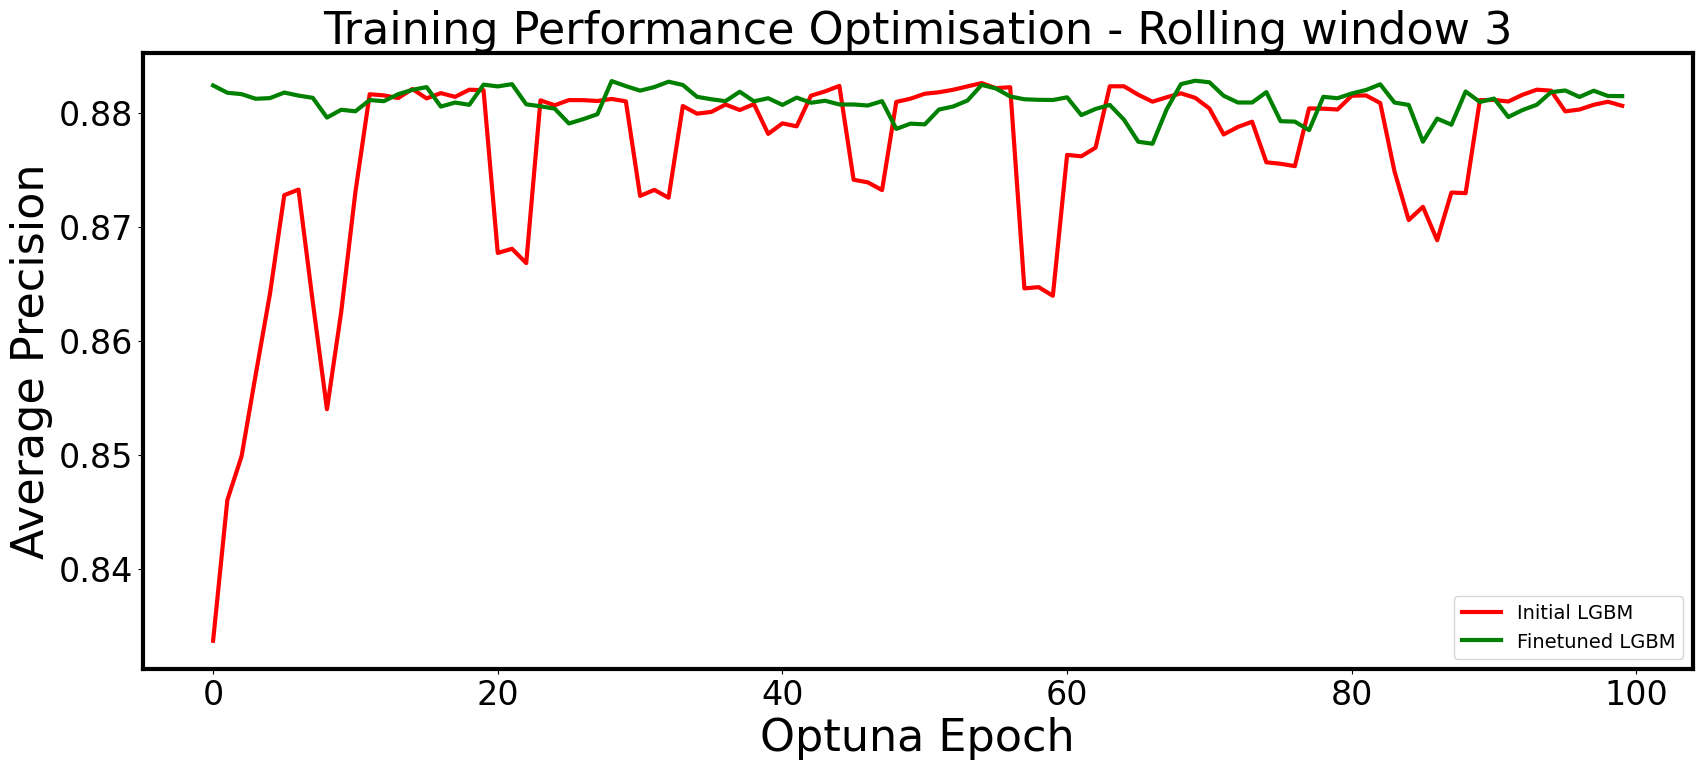

In [17]:
plt.figure(figsize=(20, 8))

plt.plot(df_trials['initial_lgbm']['number'],
         df_trials['initial_lgbm']['value'].rolling(window=3, min_periods=1).mean(),
         label='Initial LGBM',
         color='red',
         linewidth=3)

plt.plot(df_trials['finetuned_lgbm']['number'],
         df_trials['finetuned_lgbm']['value'].rolling(window=3, min_periods=1).mean(),
         label='Finetuned LGBM',
         color='green',
         linewidth=3)

plt.xlabel('Optuna Epoch', fontsize=32)
plt.xticks(fontsize=32)
plt.ylabel('Average Precision', fontsize=32)
plt.xticks(fontsize=32)
plt.title('Training Performance Optimisation - Rolling window 3', fontsize=32)
plt.legend(fontsize=14)

ax = plt.gca()
ax.tick_params(axis='x', labelsize=24)
ax.tick_params(axis='y', labelsize=24)

for spine in ax.spines.values():
    spine.set_linewidth(3)
    
if FLAG_EXPORT:
    plt.savefig(EXPORT_PATH_FIGURE)
    
plt.show()

<h1><center>k-fold Cross Validation</center></h1>

In [19]:
model_final = lgb.LGBMClassifier(
                                 objective="binary",
                                 boosting_type="gbdt",
                                 scale_pos_weight=class_weight,
                                 importance_type="gini",
                                 random_state=42,
                                 verbosity=-1,
                                 n_jobs=-1,
                                 **finetuned_study.best_params
                                 )

scores_cv = optuna_obj.run_cv(folds=10,
                              clf=model_final)

Fold 1, metric score = 0.88
Fold 2, metric score = 0.89
Fold 3, metric score = 0.89
Fold 4, metric score = 0.89
Fold 5, metric score = 0.89
Fold 6, metric score = 0.89
Fold 7, metric score = 0.89
Fold 8, metric score = 0.88
Fold 9, metric score = 0.89
Fold 10, metric score = 0.89

Mean metric score for all 10 CV folds:0.89 +/- 0.00


<h1><center>Train the Final Model</center></h1>

In [20]:
model_final.fit(X_train,
                y_train,
                eval_set=[(X_val, y_val)],
                eval_metric="average_precision",
                callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])

,boosting_type,'gbdt'
,num_leaves,109
,max_depth,6
,learning_rate,0.18465585433134318
,n_estimators,155
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,12


<h1><center>Export to .pkl</center></h1>

In [21]:
if FLAG_EXPORT:
    optuna_obj.pickle_export(path=EXPORT_PATH_MODEL,
                             file=model_final)